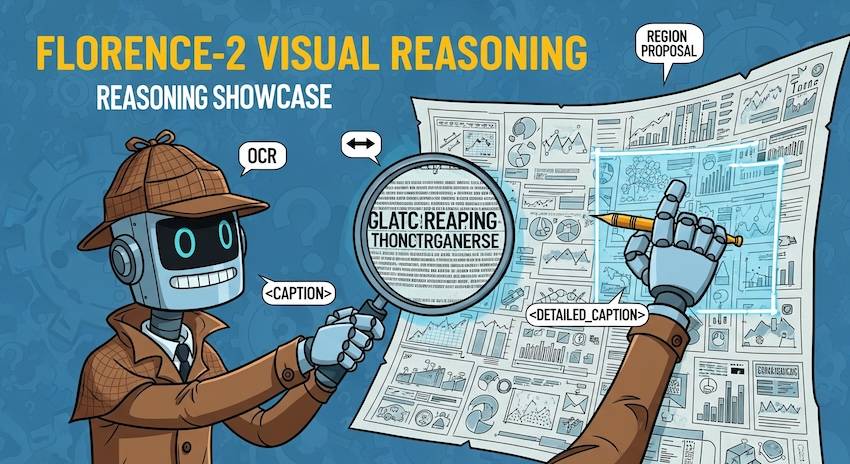

# README Summary

This notebook demonstrates various visual reasoning tasks using the Florence-2 model, including:

- **Object Detection (`<CAPTION>`)**: Generating a concise caption for the image.
- **Detailed Captioning (`<DETAILED_CAPTION>` and `<MORE_DETAILED_CAPTION>`)**: Providing more descriptive captions of the image content.
- **OCR with Region (`<OCR_WITH_REGION>`)**: Performing Optical Character Recognition and identifying the regions of the text.
- **Caption to Phrase Grounding (`<CAPTION_TO_PHRASE_GROUNDING>`)**: Grounding phrases from a caption to specific regions in the image.
- **Open Vocabulary Detection (`<OPEN_VOCABULARY_DETECTION>`)**: Detecting objects based on a given text query.
- **Dense Region Captioning (`<DENSE_REGION_CAPTION>`)**: Generating captions for multiple regions within the image.
- **Region Proposal (`<REGION_PROPOSAL>`)**: Proposing potential regions of interest in the image.
- **OCR (`<OCR>`)**: Performing Optical Character Recognition on the entire image.
- **Region to Category (`<REGION_TO_CATEGORY>`)**: Classifying the content within a specified region.
- **Region to Description (`<REGION_TO_DESCRIPTION>`)**: Generating a description of the content within a specified region.

The notebook utilizes the `transformers` library for loading and running the Florence-2 model, `supervision` for handling detections and annotations, and `jupyter_bbox_widget` for interactive bounding box selection.

The analysis was performed on a PDF document converted to an image (`Graph-Algorithms-Infographic.pdf`).

In [ ]:
# Check if the runtime environment has access to a GPU
!nvidia-smi

Wed Aug 28 14:07:23 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
files = !ls
files = files[-1].split('  ')
display(files)
pdf_path = files[0]
pdf_path

['Graph-Algorithms-Infographic.pdf', 'sample_data']

'Graph-Algorithms-Infographic.pdf'

In [ ]:
!pip install pymupdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 103.0 MB/s eta 0:00:00


In [ ]:
import fitz

pdf_document = fitz.open(pdf_path)

page = pdf_document.load_page(0)

pix = page.get_pixmap()

image_path = f'{pdf_path}_{0}.png'
pix.save(image_path)

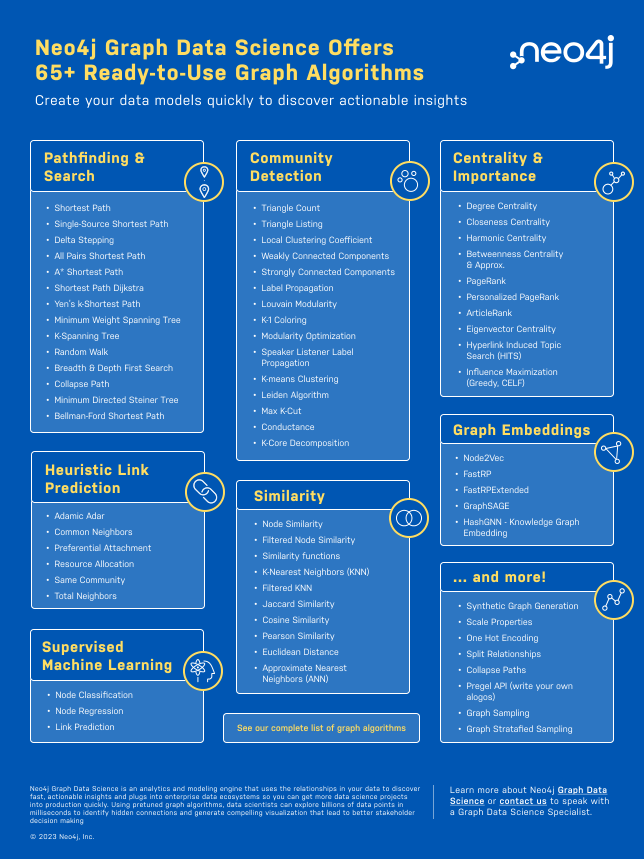

In [ ]:
from IPython.display import Image, display, Audio, Markdown
display(Image(image_path))

In [ ]:
!pip install openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.9/362.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.9 MB/s eta 0:00:00


In [ ]:
from openai import AzureOpenAI
from google.colab import userdata
client = AzureOpenAI(
    api_key=userdata.get('AZURE_API_KEY'),
    api_version=userdata.get('AZURE_API_VERSION'),
    azure_endpoint=userdata.get('AZURE_BASE_URL')
)

In [ ]:
system_prompt = "You are a helpful assistant that responds in Markdown. Help me to read the infographic"
user_prompt = "What are the similarity algorithms?"

In [ ]:
import base64
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

base64_image = encode_image(image_path)

response = client.chat.completions.create(
    model=userdata.get('AZURE_MODEL_NAME'),
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": [
            {"type": "text", "text": user_prompt},
            {"type": "image_url", "image_url": {
                "url": f"data:image/png;base64,{base64_image}"}
            }
        ]}
    ],
    temperature=1e-4,
    max_tokens=1024,
)

print(response.choices[0].message.content)

The similarity algorithms listed in the infographic are:

- Node Similarity
- Filtered Node Similarity
- Similarity Functions
- K-Nearest Neighbors (KNN)
- Filtered KNN
- Jaccard Similarity
- Cosine Similarity
- Pearson Similarity
- Euclidean Distance
- Approximate Nearest Neighbors (aNN)


In [ ]:
import os
import google.generativeai as genai

genai.configure(api_key=userdata.get("GOOGLE_API_KEY"))

generation_config = {
  "temperature": 1e-4,
  "top_p": 0.95,
  "top_k": 64,
  "max_output_tokens": 1024,
  "response_mime_type": "text/plain",
}

model = genai.GenerativeModel(
  model_name="gemini-1.5-flash",
  generation_config=generation_config,
  system_instruction=system_prompt,
)

files = [
  genai.upload_file(image_path, mime_type=None),
]

chat_session = model.start_chat(
  history=[
    {
      "role": "user",
      "parts": [
        files[0],
      ],
    },
  ]
)

response = chat_session.send_message(user_prompt)

print(response.text)

The similarity algorithms are:
- Node Similarity
- Filtered Node Similarity
- Similarity functions
- K-Nearest Neighbors (KNN)
- Filtered KNN
- Jaccard Similarity
- Cosine Similarity
- Pearson Similarity
- Euclidean Distance
- Approximate Nearest Neighbors (ANN) 



In [ ]:
!pip install -q transformers flash_attn timm einops supervision==0.22.0rc1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 49.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.9/126.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.2 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor

# CHECKPOINT = "microsoft/Florence-2-base-ft"
CHECKPOINT = "microsoft/Florence-2-large-ft"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(CHECKPOINT, trust_remote_code=True).to(DEVICE)
processor = AutoProcessor.from_pretrained(CHECKPOINT, trust_remote_code=True)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.44k [00:00<?, ?B/s]

configuration_florence2.py:   0%|          | 0.00/15.1k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large-ft:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py:   0%|          | 0.00/127k [00:00<?, ?B/s]

...

processing_florence2.py:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large-ft:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
# @title Use case: object detection (`<CAPTION>`) inference
import supervision as sv
from PIL import Image

image = Image.open(image_path)
display(image.size)

def run_inference(image: Image, task: str, text: str = ""):
    prompt = task + text
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(DEVICE)
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        num_beams=3
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return processor.post_process_generation(generated_text, task=task, image_size=image.size)

(644, 859)

In [ ]:
task = "<CAPTION>"

response = run_inference(image=image, task=task)
response

{'<CAPTION>': 'A poster with information about graph data science.'}

In [ ]:
task = "<DETAILED_CAPTION>"

response = run_inference(image=image, task=task)
response

{'<DETAILED_CAPTION>': 'In this image we can see a poster with some text on it.'}

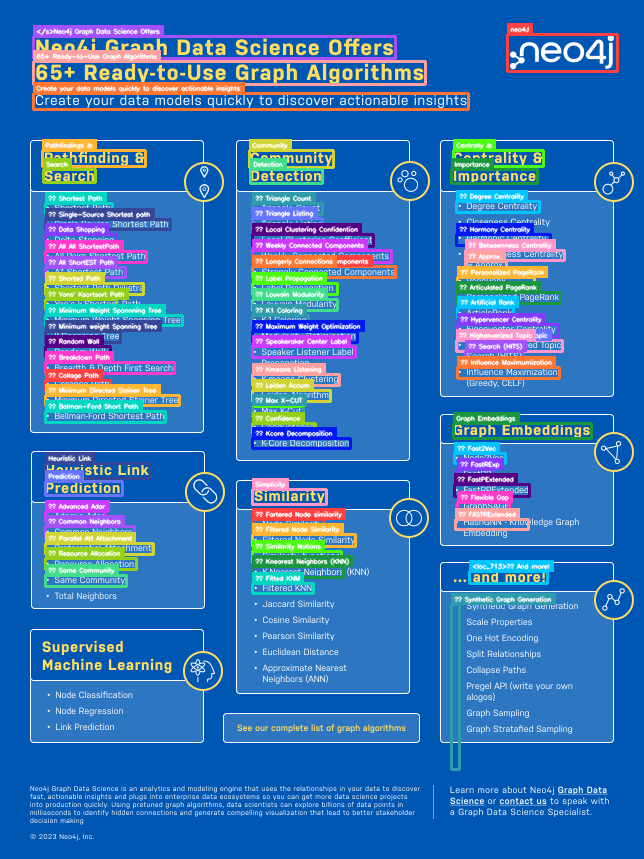

In [ ]:
task = "<OCR_WITH_REGION>"
image = Image.open(image_path)
response = run_inference(image=image, task=task)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(
    color_lookup=sv.ColorLookup.INDEX,
    text_scale=0.2,
    text_padding=3,
    text_thickness=1
)

image_result = bounding_box_annotator.annotate(image, detections)
image_result = label_annotator.annotate(image, detections)
# image_result.thumbnail((600,600))
image_result

In [ ]:
task = "<DETAILED_CAPTION>"
image = Image.open(image_path)

response = run_inference(image=image, task=task)
response

{'<DETAILED_CAPTION>': 'In this image we can see a poster with some text on it.'}

In [ ]:
task = "<MORE_DETAILED_CAPTION>"

response = run_inference(image=image, task=task)
response

{'<MORE_DETAILED_CAPTION>': 'A poster that is titled "Neo4j Graph Data Science Offers 65+ Ready-to-Use Graph Algorithms". The poster has a blue background with white text. The title of the poster is in bold white letters at the top. Below the title is a list of steps to create your data models quickly to discover actionable insights.  '}

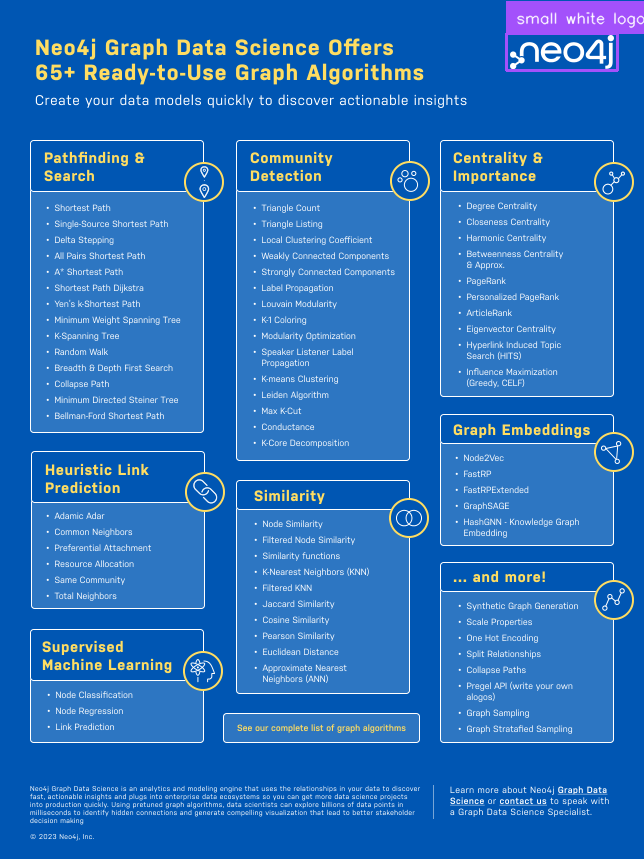

In [ ]:
task = "<CAPTION_TO_PHRASE_GROUNDING>"
text = "small white logo text"
image = Image.open(image_path)

response = run_inference(image=image, task=task, text=text)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)
image_

In this image we can see a poster with some text on it.


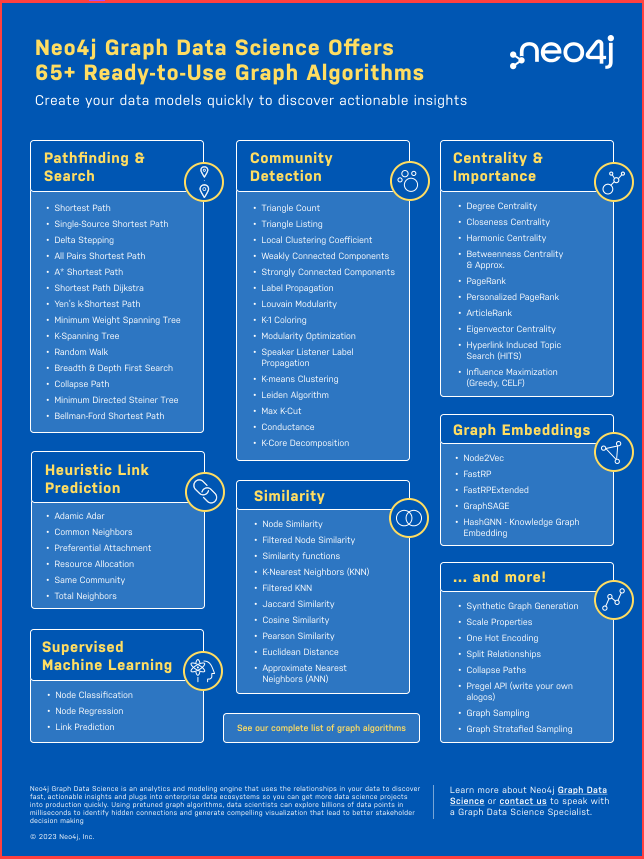

In [ ]:
image = Image.open(image_path)
task = "<DETAILED_CAPTION>"

response = run_inference(image=image, task=task)
text = response[task]

task = "<CAPTION_TO_PHRASE_GROUNDING>"

response = run_inference(image=image, task=task, text=text)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)

print(text)
image_

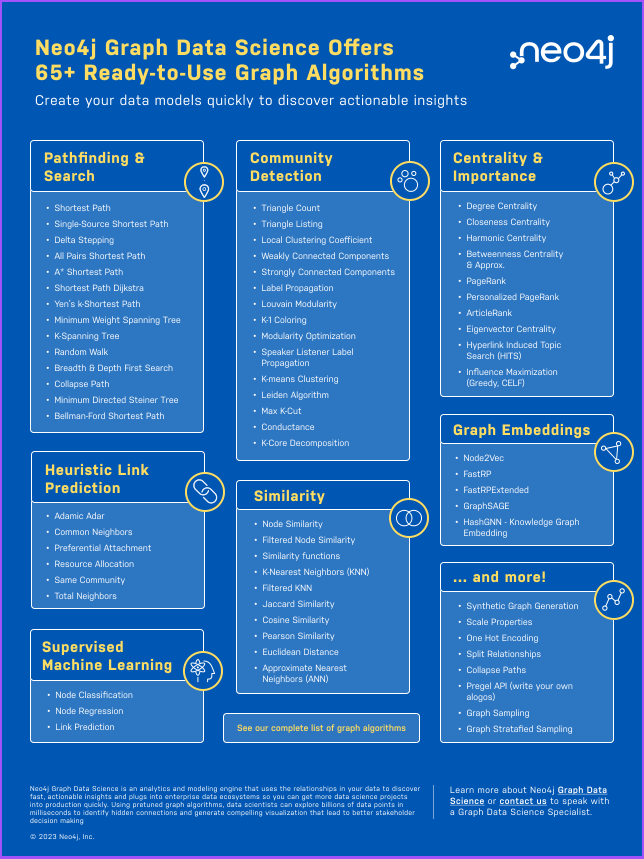

In [ ]:
image = Image.open(image_path)
task = "<OPEN_VOCABULARY_DETECTION>"
text = "similarity table"

response = run_inference(image=image, task=task, text=text)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)
# image.thumbnail((600, 600))
image_

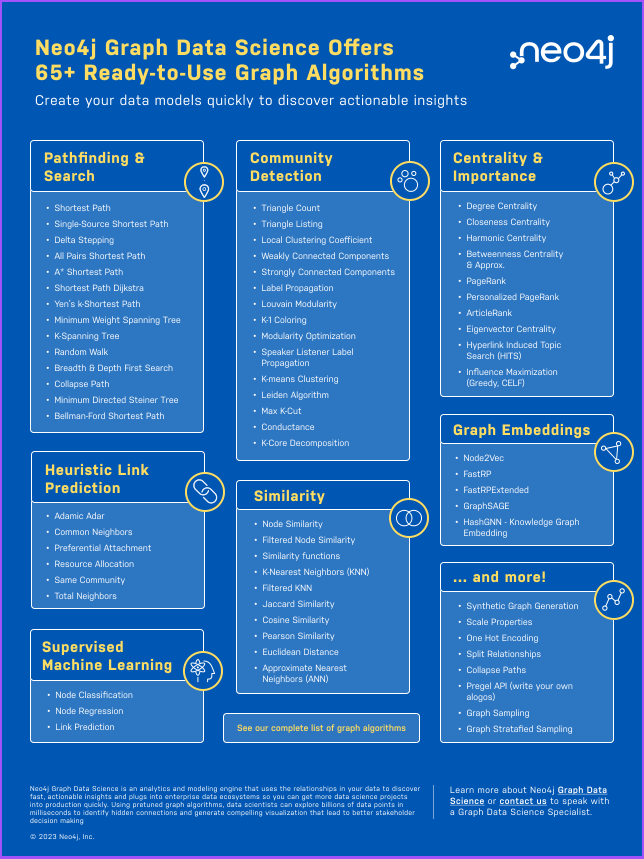

In [ ]:
task = "<DENSE_REGION_CAPTION>"
image = Image.open(image_path)

response = run_inference(image=image, task=task)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)
image_

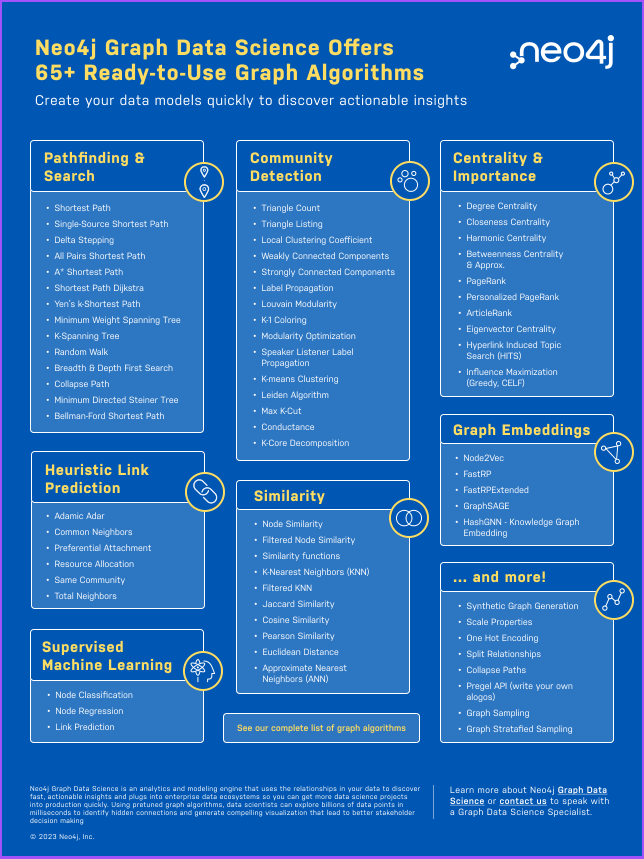

In [ ]:
task = "<REGION_PROPOSAL>"
image = Image.open(image_path)

response = run_inference(image=image, task=task)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)
image_

In [ ]:
task = "<OCR>"
image = Image.open(image_path)

response = run_inference(image=image, task=task)
response

{'<OCR>': "Neo4j Graph Data Science Offersne04j65+ Ready-to-Use Graph AlgorithmsCreate your data models quickly to discover actionable insightsPathfindings &CommunityCentrality &SearchSearchDetectionImportance· Shortest Path· Triangle Count· Degree Centrality· Single-Source Shortest path· Triangle Listing· Degree Centrality· Delta Stopping· Local Clustering ConfidentHarmonic Centrally· All Airs shortest Path· Weekly Connected Components. Betweenness Centrality. All All Shortest PATH· Strongly Connected ConnectionsBathroomness Centralty. A ShortestPath· All All Shorter Path· Longally Connected components· Approx.A Shortestpath· Longingly Connected Components· Personalized PageRank· Yan's Ksortsort Path·Shortest Path Dijktra· Label Propagation· Louvain Modularity· Articulated PageRank. Minimum Weight Spaning Tree· K1 Coloring· Artistic Rank· Minimum Weightspanning Tree· Hygenverized Centralty· Maximum Weight Optimization· Hyperink Induced Topic· Random Wall.Speakeraker Optimization. Hyge

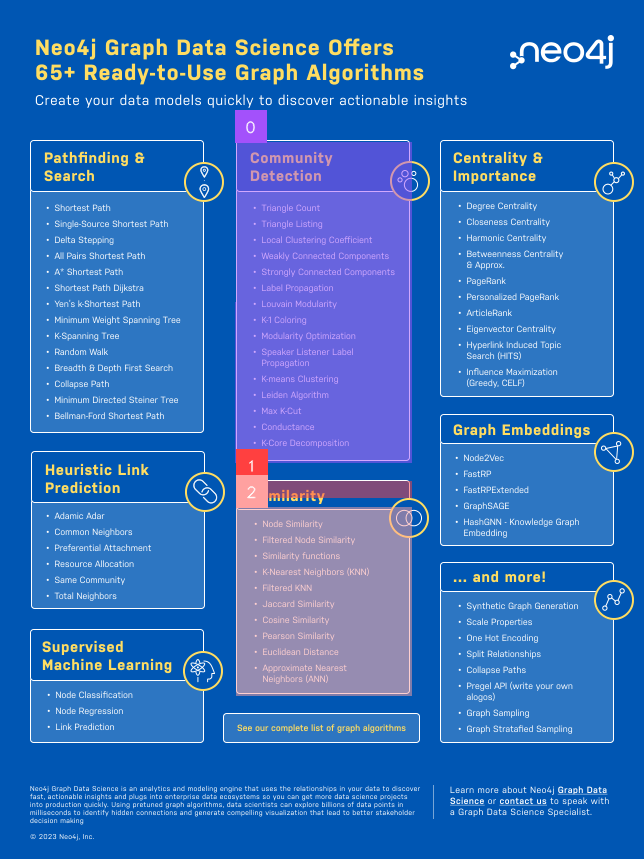

In [ ]:
task = "<REFERRING_EXPRESSION_SEGMENTATION>"
text = "circle"
image = Image.open(image_path)

response = run_inference(image=image, task=task, text=text)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)

mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = mask_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)
image_

In [ ]:
!pip install -q jupyter_bbox_widget

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.4/727.4 kB 37.7 MB/s eta 0:00:00


In [ ]:
import base64

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

In [ ]:
IS_COLAB = True

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

widget = BBoxWidget()
widget.image = encode_image(image_path)
widget

BBoxWidget(colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#b…

In [ ]:
widget.bboxes

[{'x': 232, 'y': 474, 'width': 199, 'height': 230, 'label': ''}]

In [ ]:
import numpy as np

# default_box is going to be used if you will not draw any box on image above
default_box = {'x': 232, 'y': 474, 'width': 199, 'height': 230, 'label': ''}

box = widget.bboxes[0] if widget.bboxes else default_box
box = np.array([
    box['x'],
    box['y'],
    box['x'] + box['width'],
    box['y'] + box['height']
])

image = Image.open(image_path)
w, h = image.size
box = box / np.array([w, h, w, h])
box = box * 1000
box = box.astype(np.int32)
box

array([360, 551, 669, 819], dtype=int32)

In [ ]:
region = "".join([f"<loc_{coordinate}>" for coordinate in box])
region

'<loc_360><loc_551><loc_669><loc_819>'

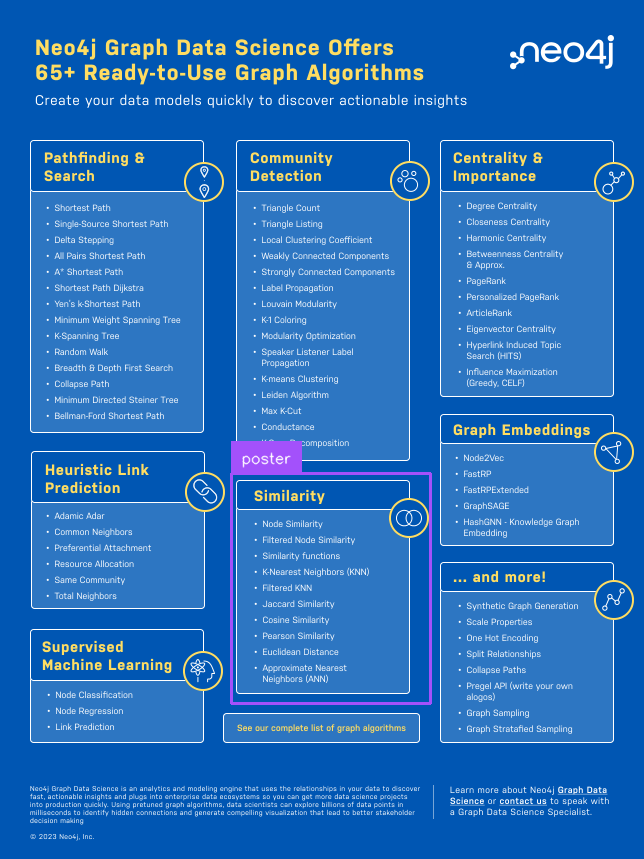

In [ ]:
task = "<REGION_TO_CATEGORY>"
image = Image.open(image_path)

response = run_inference(image=image, task=task, text=region)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)
detections.xyxy = (detections.xyxy / 1000 * np.array([w, h, w, h])).astype(np.int32)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)

image_

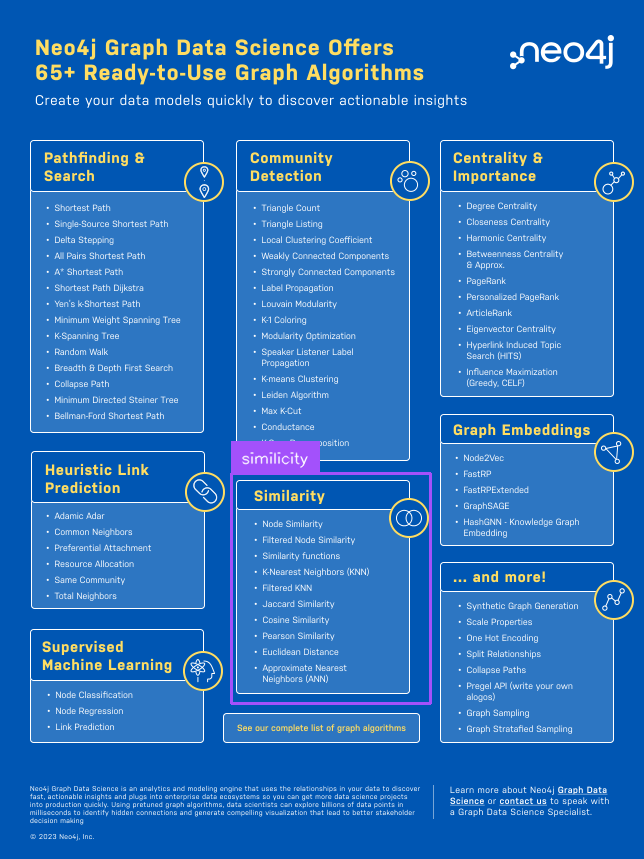

In [ ]:
task = "<REGION_TO_DESCRIPTION>"
image = Image.open(image_path)

response = run_inference(image=image, task=task, text=region)
detections = sv.Detections.from_lmm(sv.LMM.FLORENCE_2, response, resolution_wh=image.size)
detections.xyxy = (detections.xyxy / 1000 * np.array([w, h, w, h])).astype(np.int32)

bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

image_ = bounding_box_annotator.annotate(image, detections)
image_ = label_annotator.annotate(image, detections)

image_